Load dataset

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
file_path = "../../dataset/prepared/ClassifierPreparedDataset.csv"
df = pd.read_csv(file_path)

df

,NLOS,RANGE,FP_IDX,FP_AMP1,FP_AMP2,CIR_PWR,MAX_NOISE,RXPACC
0,0.0,3.90,745.0,18712.0,10250.0,11855.0,967.0,611.0
1,0.0,0.66,749.0,11239.0,6313.0,18968.0,1133.0,447.0
2,1.0,7.86,746.0,4355.0,5240.0,14699.0,894.0,723.0
3,1.0,3.48,750.0,8502.0,8416.0,8748.0,1127.0,1024.0
4,0.0,1.19,746.0,17845.0,18095.0,11380.0,1744.0,276.0
...,...,...,...,...,...,...,...,...
41995,0.0,2.43,745.0,12960.0,17703.0,9987.0,2379.0,276.0
41996,0.0,1.39,745.0,2235.0,15089.0,12559.0,1810.0,281.0
41997,1.0,5.48,747.0,7115.0,6262.0,1435.0,1092.0,1024.0
41998,1.0,3.40,745.0,6662.0,7683.0,1491.0,1077.0,1024.0


Check if features are linear

In [3]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
import numpy as np

for col in df.columns:
    X = df[col].values.reshape(-1, 1)
    y = df["NLOS"]

    # Linear Model
    log_reg = LogisticRegression()
    log_reg.fit(X, y)
    y_pred_linear = log_reg.predict_proba(X)[:, 1]

    # Polynomial Model (Degree 2)
    poly = PolynomialFeatures(degree=2)
    X_poly = poly.fit_transform(X)
    log_reg_poly = LogisticRegression()
    log_reg_poly.fit(X_poly, y)
    y_pred_poly = log_reg_poly.predict_proba(X_poly)[:, 1]

    # Compare AUC Scores
    auc_linear = roc_auc_score(y, y_pred_linear)
    auc_poly = roc_auc_score(y, y_pred_poly)

    print(f"Column: {col}")
    print(f"Linear Model AUC: {auc_linear:.4f}")
    print(f"Polynomial Model AUC: {auc_poly:.4f}\n")

Column: NLOS
Linear Model AUC: 1.0000
Polynomial Model AUC: 1.0000

Column: RANGE
Linear Model AUC: 0.7572
Polynomial Model AUC: 0.7572

Column: FP_IDX
Linear Model AUC: 0.6987
Polynomial Model AUC: 0.6987

Column: FP_AMP1
Linear Model AUC: 0.7611
Polynomial Model AUC: 0.6914

Column: FP_AMP2
Linear Model AUC: 0.7968
Polynomial Model AUC: 0.7406

Column: CIR_PWR
Linear Model AUC: 0.7437
Polynomial Model AUC: 0.7437

Column: MAX_NOISE
Linear Model AUC: 0.6050
Polynomial Model AUC: 0.6050

Column: RXPACC
Linear Model AUC: 0.9047
Polynomial Model AUC: 0.9047



Extract NLOS column and put into y as class labels

In [4]:
X = df.drop(columns=["NLOS"])
y = df["NLOS"]

Split dataset into training and testing with 70:30 ratio


In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (29400, 7)
X_test shape: (12600, 7)


Scale features with StandardScaler

In [6]:
from sklearn.preprocessing import StandardScaler

print("Before Scaling:")
print(X_train.shape)
print(X_train.head())

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("After Scaling:")
print(X_train.shape)
print(X_train[0:5])

Before Scaling:
(29400, 7)
       RANGE  FP_IDX  FP_AMP1  FP_AMP2  CIR_PWR  MAX_NOISE  RXPACC
32141   3.38   744.0   4796.0  16013.0  10498.0      831.0   412.0
10895   4.20   742.0   1714.0   5390.0   6967.0     1134.0  1024.0
2087    9.20   739.0   4056.0   3165.0   8330.0     1080.0  1025.0
35565   5.65   742.0   2162.0    623.0   4437.0      970.0  1024.0
4351    1.88   751.0  11704.0   6288.0  11470.0     1494.0   276.0
After Scaling:
(29400, 7)
[[-0.19113517 -0.3677422  -0.61759027  0.7355948   0.14728    -0.83892358
  -0.66476221]
 [ 0.15566223 -0.81861151 -1.18923249 -0.96721231 -0.57364969 -0.31824922
   1.32534983]
 [ 2.2702805  -1.49491548 -0.75484375 -1.32386728 -0.29536389 -0.41104267
   1.32860164]
 [ 0.76890153 -0.81861151 -1.10613849 -1.73133557 -1.09020367 -0.60006636
   1.32534983]
 [-0.82552065  1.21030039  0.66368958 -0.82326796  0.34573473  0.30037379
  -1.10700934]]


Train model using different C hyperparameter values

Text(0, 0.5, 'Score')

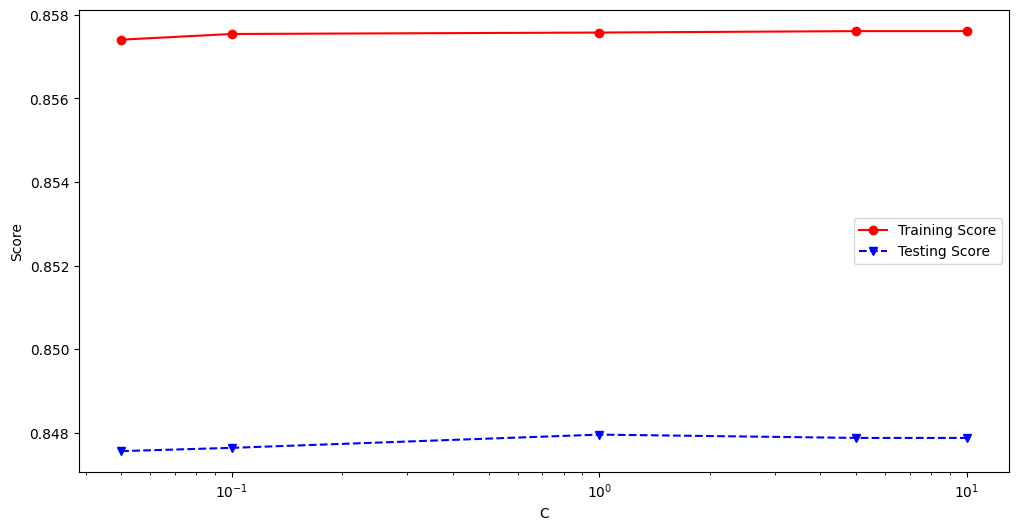

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

C = [0.05, 0.1, 1, 5, 10]

LRTrainAcc = []
LRTestAcc = []

for c in C:
    # Create and train the Logistic Regression model
    logreg = LogisticRegression(C=c, solver='liblinear')
    logreg.fit(X_train, y_train)

    # Predict on the training set
    y_pred_train = logreg.predict(X_train)
    # Predict on the test set
    y_pred_test = logreg.predict(X_test)

    # Evaluate the performance
    train_accuracy_logreg = roc_auc_score(y_train, y_pred_train)
    test_accuracy_logreg = roc_auc_score(y_test, y_pred_test)

    LRTrainAcc.append(train_accuracy_logreg)
    LRTestAcc.append(test_accuracy_logreg)
    

fig, (ax1) = plt.subplots(1, 1, figsize=(12,6))
ax1.plot(C, LRTrainAcc, 'ro-', C, LRTestAcc,'bv--')
ax1.legend(['Training Score','Testing Score'])
ax1.set_xlabel('C')
ax1.set_xscale('log')
ax1.set_ylabel('Score')

AUC-ROC score: 84.76%
Confusion Matrix:
[[5670  618]
 [1304 5008]]


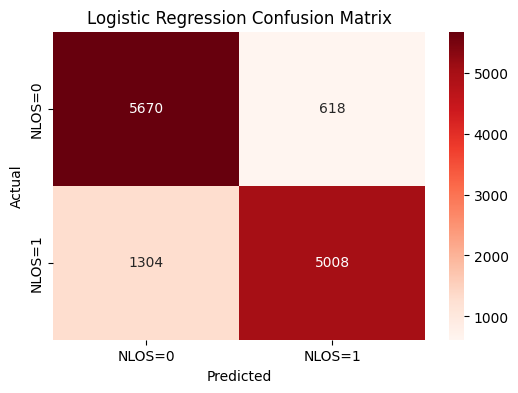


Classification Report:
              precision    recall  f1-score   support

         0.0       0.81      0.90      0.86      6288
         1.0       0.89      0.79      0.84      6312

    accuracy                           0.85     12600
   macro avg       0.85      0.85      0.85     12600
weighted avg       0.85      0.85      0.85     12600



In [ ]:
# Do logistic regression again with best C hyperparameter
log_reg = LogisticRegression(C=0.05, solver='liblinear')
log_reg.fit(X_train, y_train)
y_pred_test = log_reg.predict(X_test)
test_accuracy_logreg = roc_auc_score(y_test, y_pred_test)

print("AUC-ROC score: {:.2f}%".format(test_accuracy_logreg * 100))

# Compute and display the confusion matrix
cm_logreg = confusion_matrix(y_test, y_pred_test)
print("Confusion Matrix:")
print(cm_logreg)

plt.figure(figsize=(6,4))
sns.heatmap(cm_logreg, annot=True, fmt="d", cmap="Reds",
            xticklabels=["NLOS=0", "NLOS=1"],
            yticklabels=["NLOS=0", "NLOS=1"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

# Print a classification report which includes precision, recall, f1 score
print("\nClassification Report:")
print(classification_report(y_test, y_pred_test))